<a href="https://colab.research.google.com/github/Alk207-lab/-Machine-learning-projects-Sem1/blob/main/multiplelin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction — Multiple Linear Regression

Dataset: `Housing.csv` (columns: `price`, `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`)

This is the multiple-feature version of the simple linear regression notebook: instead of predicting `price` from `area` alone, we use **all available columns** as features.

1. Import data
2. Basic preprocessing (encode categorical columns)
3. Visualize the data (correlation heatmap)
4. Train/test split
5. Train a Multiple Linear Regression model
6. Report coefficients & intercept
7. Report accuracy metrics
8. Visualize actual vs. predicted price
9. Predict price for a new house

> Note: `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea` are yes/no columns, and `furnishingstatus` is a 3-level category — both need encoding before they can go into a linear model.
## Step 0: Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")


## Step 1: Import the Data

In [3]:
# --- Uncomment this block if running on Google Colab and need to upload the file ---
# from google.colab import files
# uploaded = files.upload()  # select Housing.csv when prompted
# ------------------------------------------------------------------------------------

excel_file ="/content/Housing.xlsx"
df = pd.read_excel(excel_file)
df.to_csv("Housing.csv",index=False)
# Quick look at the data
print("Shape:", df.shape)
print(df.head())
print(df.info())


Shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data colum

## Step 2: Basic Data Preprocessing

Since we're using every column this time, preprocessing needs to do a bit more than in the simple-regression notebook:

- Check for missing values
- Map the yes/no columns to 1/0
- One-hot encode `furnishingstatus` (3 categories → 2 dummy columns, dropping one level to avoid the dummy-variable trap)
- Drop duplicates / missing rows if any


In [4]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

data = df.copy()

# Map binary yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus (drop_first avoids the dummy variable trap)
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

# Drop any missing or duplicate rows
data = data.dropna()
data = data.drop_duplicates()

print("Final shape after cleaning:", data.shape)
data.head()


Missing values per column:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Final shape after cleaning: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Step 3: Visualize the Data (Correlation Heatmap)

With a single feature a scatter plot was enough. With multiple features, a correlation heatmap is more useful for spotting which variables move with `price` — and which features are correlated with *each other* (a heads-up for multicollinearity).


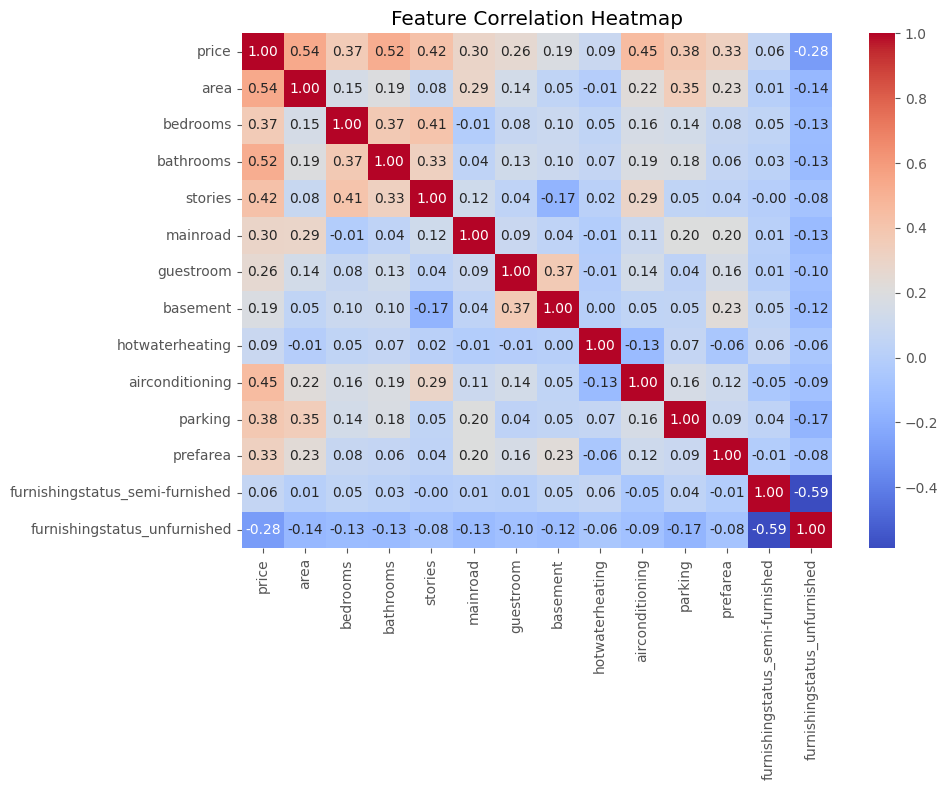

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## Step 4: Train/Test Split

We split the data into training (80%) and testing (20%) sets. `X` now holds every column except `price`.


In [6]:
X = data.drop(columns=['price'])   # All features
y = data['price']                  # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Features used   :", list(X.columns))


Training samples: 436
Testing samples : 109
Features used   : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


## Step 5: Train the Multiple Linear Regression Model


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")


Model trained successfully!


## Step 6: Coefficients and Intercept

For multiple linear regression: `price = b1*x1 + b2*x2 + ... + bn*xn + intercept`

Each coefficient is the change in price for a one-unit increase in that feature, holding all other features constant.


In [8]:
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coeffs.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")


                        Feature   Coefficient
                      bathrooms  1.094445e+06
                airconditioning  7.914267e+05
                hotwaterheating  6.846499e+05
                       prefarea  6.298906e+05
   furnishingstatus_unfurnished -4.136451e+05
                        stories  4.074766e+05
                       basement  3.902512e+05
                       mainroad  3.679199e+05
                      guestroom  2.316100e+05
                        parking  2.248419e+05
furnishingstatus_semi-furnished -1.268818e+05
                       bedrooms  7.677870e+04
                           area  2.359688e+02

Intercept: 260032.3576


## Step 7: Accuracy Metrics

Same metrics as before, plus **Adjusted R²**, which corrects R² for the number of features used (useful once you're no longer down to a single predictor).




In [9]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Mean Absolute Error (MAE) : {mae:,.2f}")
print(f"Mean Squared Error (MSE)  : {mse:,.2f}")
print(f"Root Mean Squared Error   : {rmse:,.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"Adjusted R² Score         : {adj_r2:.4f}")


Mean Absolute Error (MAE) : 970,043.40
Mean Squared Error (MSE)  : 1,754,318,687,330.66
Root Mean Squared Error   : 1,324,506.96
R² Score                  : 0.6529
Adjusted R² Score         : 0.6054


## Step 8: Visualize Actual vs. Predicted Price

With more than one feature we can't draw a single regression line against price. Instead: an **actual vs. predicted** scatter (points on the red line = perfect predictions) and a **residual plot** (looking for any leftover pattern, which would hint the linear model is missing something).


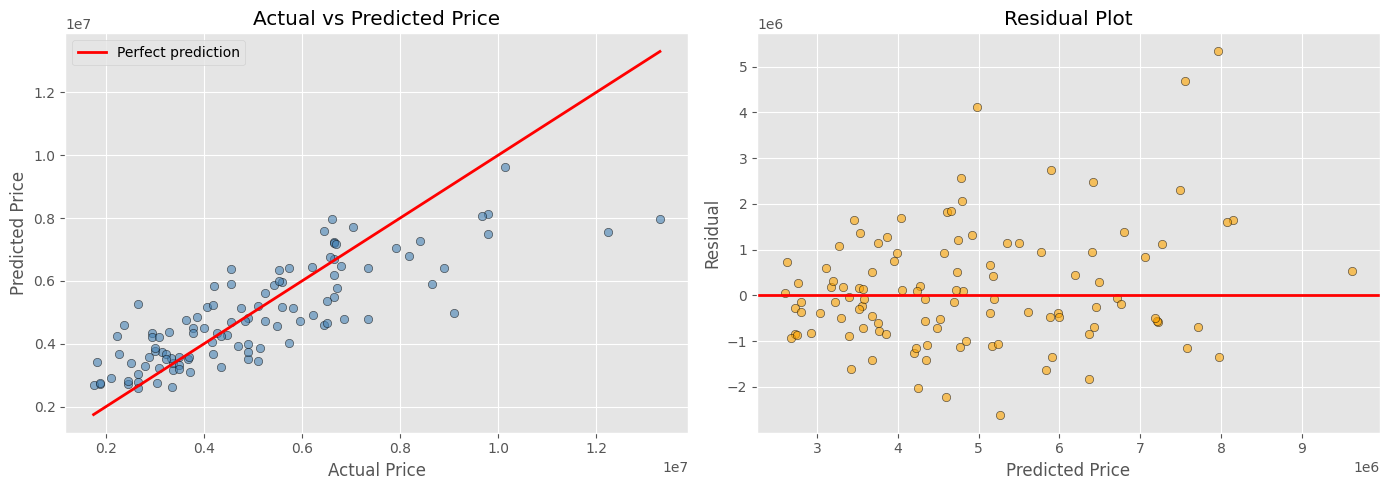

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, color='steelblue', alpha=0.6, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color='red', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted Price')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='orange', alpha=0.6, edgecolor='k')
axes[1].axhline(0, color='red', linewidth=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


## Step 9: Predict Price for a New House

Use the trained model to predict the price of a house given its full feature set. The helper function applies the same encoding used during training and lines the columns up with what the model expects.


In [11]:
def predict_price(new_data: dict):
    """Predict house price given a dict of raw feature values, e.g.:
    {
        'area': 6000, 'bedrooms': 3, 'bathrooms': 2, 'stories': 2,
        'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
        'hotwaterheating': 'no', 'airconditioning': 'yes',
        'parking': 1, 'prefarea': 'yes', 'furnishingstatus': 'semi-furnished'
    }
    """
    input_df = pd.DataFrame([new_data])

    for col in binary_cols:
        input_df[col] = input_df[col].map({'yes': 1, 'no': 0})

    input_df = pd.get_dummies(input_df, columns=['furnishingstatus'])

    # Align columns with training data (adds any missing dummy columns as 0)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    predicted_price = model.predict(input_df)[0]
    return predicted_price

# Example usage
new_house = {
    'area': 6000, 'bedrooms': 3, 'bathrooms': 2, 'stories': 2,
    'mainroad': 'yes', 'guestroom': 'no', 'basement': 'no',
    'hotwaterheating': 'no', 'airconditioning': 'yes',
    'parking': 1, 'prefarea': 'yes', 'furnishingstatus': 'semi-furnished'
}
predicted = predict_price(new_house)
print(f"Predicted price for new house: {predicted:,.2f}")


Predicted price for new house: 6,797,221.40


## Summary

- Trained a multiple linear regression model on all 12 features → `price`.
- Encoded yes/no columns as 1/0 and one-hot encoded `furnishingstatus`.
- Reported per-feature coefficients, the intercept, and evaluation metrics (MAE, MSE, RMSE, R², Adjusted R²).
- Visualized actual-vs-predicted price and residuals (no single 2D regression line, since there are multiple predictors).
- Provided a reusable `predict_price()` function that takes a dict of raw feature values and handles the encoding for you.
